In [1]:
#Installation and Imports¶
#!pip install shap xgboost --quiet
#Installs SHAP (for model explanation) and XGBoost (gradient boosting model) quietly without verbose output.
import shap
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
#Imports necessary packages:
#shap: used for generating local and global explanations of model predictions.
#xgboost: for loading the trained model.
#pandas: for loading the dataset.
#matplotlib.pyplot: for any additional plotting.


C:\Users\Grace\anaconda1\envs\grace\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
#📥 Load Dataset and Trained Model¶
df = pd.read_csv('features.csv')
#Loads the dataset with engineered features.
X = df.drop(columns=['Global_active_power', 'datetime', 'Unnamed: 0'])
#Removes the target variable and timestamp, leaving only the input features.
model = xgb.Booster()
model.load_model('xgb_energy_model.json')
#Loads the pre-trained XGBoost model saved in JSON format.

In [14]:
# ✅ Align X with what the model expects
X = X.loc[:, ~X.columns.duplicated()]  # Drop duplicate columns (if any)

# Ensure X is in the same order as model feature names
X = X[X.columns]  # Or use model.get_dump()[0] if feature_names is None

In [15]:
# Fallback: infer feature names from training data
# Save the original feature names during training if possible!
model.feature_names = list(X.columns)  # Only safe if you're 100% sure X matches training layout

In [16]:
X.columns

Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour',
       'day_of_week', 'hour_sin', 'hour_cos', 'Apparent_Power'],
      dtype='object')

In [17]:
#🧠 SHAP Explainer and Value Computation¶
explainer = shap.TreeExplainer(model)
#Creates a TreeExplainer, which is optimized for tree-based models like XGBoost.
shap_values = explainer.shap_values(X)
#Computes the SHAP values for each feature in each row.
#Each value explains how much a feature contributed to a prediction relative to the mean.

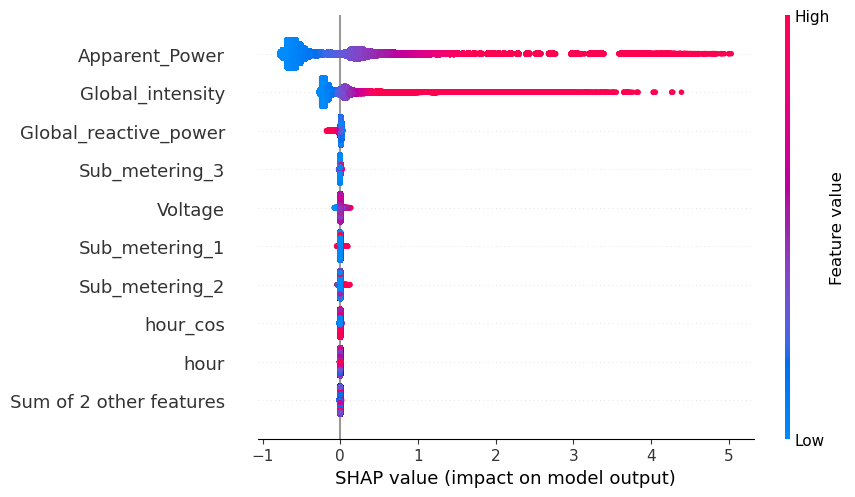

In [18]:
shap.plots.beeswarm(shap.Explanation(values=shap_values, data=X, feature_names=X.columns))

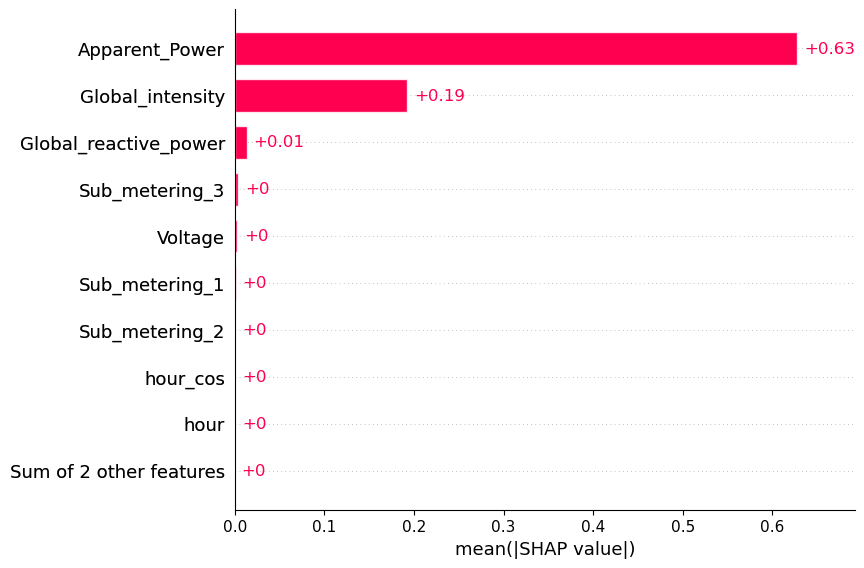

In [19]:
shap.plots.bar(shap.Explanation(values=shap_values, data=X, feature_names=X.columns))

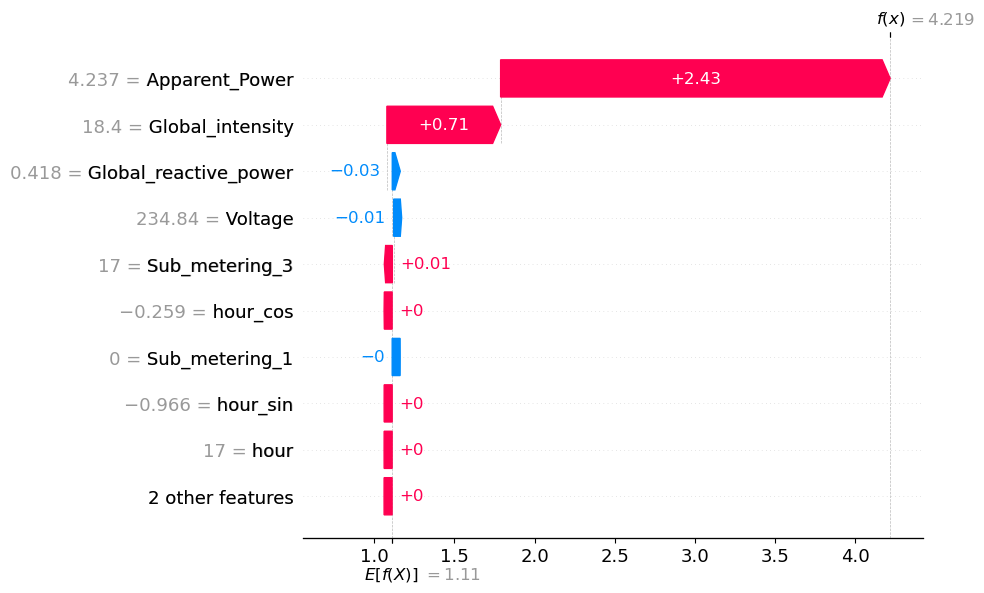

In [34]:
sample = X.iloc[[0]]  # Keep this as a 1-row DataFrame
explanation = explainer(sample)  # SHAP Explanation object with shape (1, n_features)

# Use index [0] to extract the first (and only) explanation from the matrix
shap.plots.waterfall(explanation[0])


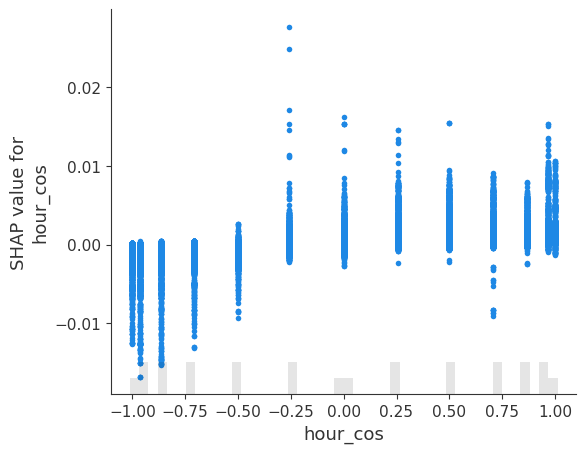

In [44]:
import shap

# Get the index of the feature
feature_name = "hour_cos"
feature_index = X.columns.get_loc(feature_name)

# Build the full Explanation object
expl = shap.Explanation(values=shap_values,data=X.values,feature_names=X.columns)

# Extract Explanation slice safely (not Series or ndarray)
shap.plots.scatter(expl[:, feature_index])



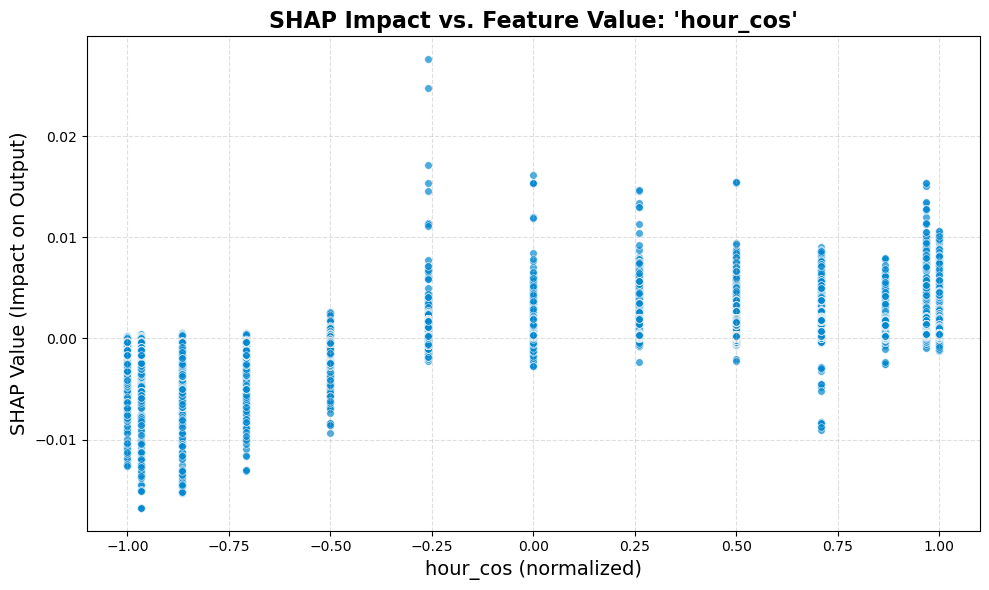

In [32]:
#traditionall method usng matplotlib libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data
feature_name = 'hour_cos'
feature_vals = X[feature_name].values
shap_vals = shap_values[:, X.columns.get_loc(feature_name)]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=feature_vals, 
    y=shap_vals, 
    s=30, 
    alpha=0.7, 
    color="#0288D1", 
    edgecolor="white", 
    linewidth=0.5
)

# Decorations
plt.title(f"SHAP Impact vs. Feature Value: '{feature_name}'", fontsize=16, fontweight='bold')
plt.xlabel(f"{feature_name} (normalized)", fontsize=14)
plt.ylabel("SHAP Value (Impact on Output)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

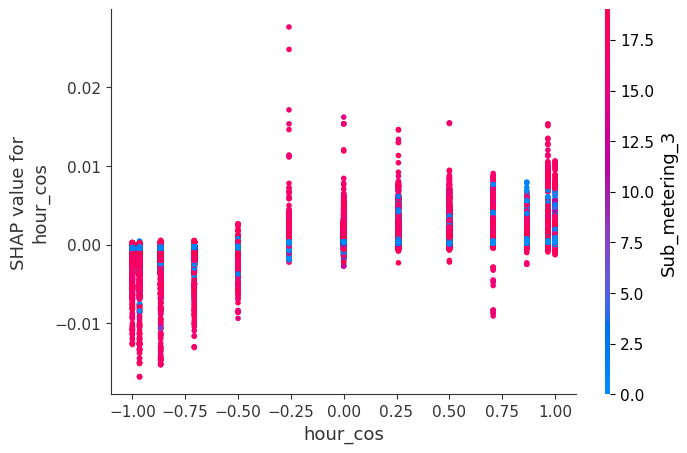

In [45]:
shap.dependence_plot("hour_cos", shap_values, X, feature_names=X.columns)